# Healthcare Appointments No-Show Analysis
## Data Cleaning and Exploratory Analysis

**Author:** Chukwuebuka Owoh  
**Dataset:** Kaggle - Medical Appointment No Shows (Brazil, 2016)  
**Raw records:** 110,527  
**Cleaned records:** 110,519  

### Notebook Structure
1. Import libraries
2. Load dataset
3. Initial exploration
4. Data cleaning
5. Feature engineering
6. Exploratory analysis and key findings
7. Export cleaned dataset

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Set consistent plot styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

## 1. Load Dataset

In [4]:
# Load the raw dataset
df = pd.read_csv("C:/Users/Admin/Downloads/archive/KaggleV2-May-2016.csv.csv")

## 2. Initial Exploration

In [6]:
# Preview the first 5 rows
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [7]:
# Summary statistics for numeric columns
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [8]:
# Row and column count
print(f'Rows:    {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows:    110527
Columns: 14


In [9]:
# Column names and data types
print(df.dtypes)

PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object


In [10]:
# Check for missing values per column
print(df.isnull().sum())

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


In [11]:
# Check for duplicate rows
# Result: 0 duplicates confirmed in this dataset
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


## 3. Data Cleaning

In [13]:
# Rename columns to snake_case for consistency with the SQL schema
df.columns = df.columns.str.lower().str.replace('-', '_')
df.rename(columns={
    'patientid':      'patient_id',
    'appointmentid':  'appointment_id',
    'scheduledday':   'scheduled_date',
    'appointmentday': 'appointment_date',
    'neighbourhood':  'clinic',
    'no_show':        'no_show'
}, inplace=True)

print('Columns renamed successfully:')
print(df.columns.tolist())

Columns renamed successfully:
['patient_id', 'appointment_id', 'gender', 'scheduled_date', 'appointment_date', 'age', 'clinic', 'scholarship', 'hipertension', 'diabetes', 'alcoholism', 'handcap', 'sms_received', 'no_show']


In [14]:
# Convert date columns from ISO string format to date objects
df['scheduled_date']  = pd.to_datetime(df['scheduled_date']).dt.date
df['appointment_date'] = pd.to_datetime(df['appointment_date']).dt.date

print('Date columns converted successfully.')

Date columns converted successfully.


In [15]:
# Inspect age distribution before filtering
print('Age distribution before cleaning:')
print(df['age'].describe())
print(f'\nRecords with age < 0:   {(df["age"] < 0).sum()}')
print(f'Records with age > 100: {(df["age"] > 100).sum()}')

Age distribution before cleaning:
count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: age, dtype: float64

Records with age < 0:   1
Records with age > 100: 7


In [16]:
# Remove records with invalid ages (outside 0 to 100 range)
# This removes 8 records: those with age = -1 and age > 100
rows_before = len(df)
df = df[(df['age'] >= 0) & (df['age'] <= 100)]
rows_removed = rows_before - len(df)

print(f'Rows removed due to invalid age: {rows_removed}')
print(f'Rows remaining: {len(df)}')

Rows removed due to invalid age: 8
Rows remaining: 110519


In [17]:
# Handle missing clinic names
# No null clinic values exist in this dataset but the fill is kept
# as a safeguard for future data loads
null_clinics = df['clinic'].isnull().sum()
df['clinic'] = df['clinic'].fillna('Unknown')

print(f'Null clinic values filled: {null_clinics}')

Null clinic values filled: 0


## 4. Feature Engineering

In [19]:
# Calculate wait_days: number of days between booking and appointment
# Negative values indicate data entry errors (appointment date before scheduled date)
df['wait_days'] = (
    pd.to_datetime(df['appointment_date']) -
    pd.to_datetime(df['scheduled_date'])
).dt.days

print('wait_days distribution:')
print(df['wait_days'].describe())
print(f'\nRecords with negative wait_days: {(df["wait_days"] < 0).sum()}')

wait_days distribution:
count    110519.000000
mean         10.183887
std          15.255169
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: wait_days, dtype: float64

Records with negative wait_days: 5


In [20]:
# Convert no_show from text to binary integer
# 1 = Patient did NOT attend (no-show)
# 0 = Patient attended
df['no_show'] = df['no_show'].map({'Yes': 1, 'No': 0})

print('no_show value counts:')
print(df['no_show'].value_counts())

no_show value counts:
no_show
0    88203
1    22316
Name: count, dtype: int64


## 5. Exploratory Analysis and Key Findings

Overall no-show rate:
no_show
Attended    79.807997
No-Show     20.192003
Name: proportion, dtype: float64


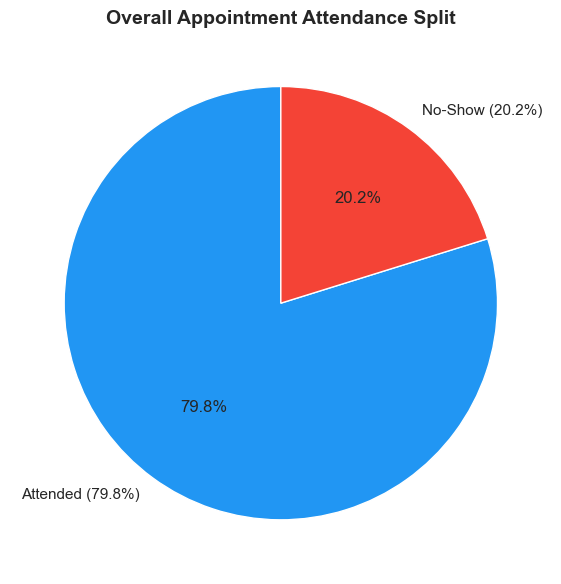

In [22]:
# Overall no-show rate
# Finding: 20.2% of patients did not attend their appointment
no_show_rate = df['no_show'].value_counts(normalize=True) * 100
print('Overall no-show rate:')
print(no_show_rate.rename({0: 'Attended', 1: 'No-Show'}))

# Visualisation: Overall no-show split
labels = ['Attended (79.8%)', 'No-Show (20.2%)']
sizes  = [no_show_rate[0], no_show_rate[1]]
colors = ['#2196F3', '#F44336']

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Overall Appointment Attendance Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

No-show rate by SMS status:
No SMS          16.70
SMS Received    27.58
Name: no_show, dtype: float64


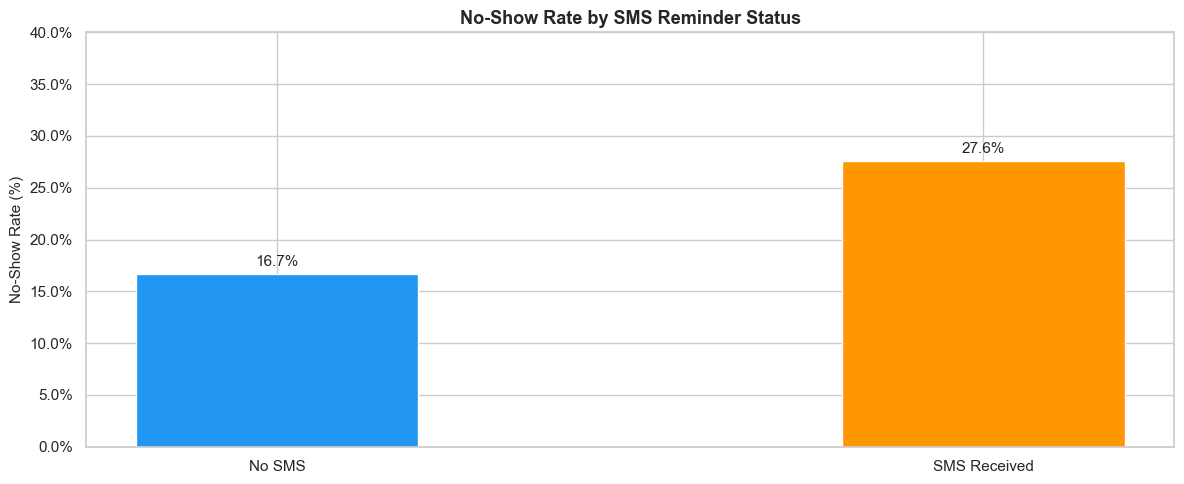

In [23]:
# No-show rate by SMS received status

# COUNTERINTUITIVE FINDING:
# Patients who received an SMS reminder had a HIGHER no-show rate (27.6%)
# compared to those who received no reminder (16.7%).

# This does NOT mean SMS reminders cause no-shows.
# The most likely explanation is confounding with wait time:
# SMS reminders appear to have been sent more frequently to patients
# with longer wait times, and longer wait times independently predict
# higher no-show rates. Further analysis controlling for wait time
# is needed before drawing conclusions about reminder effectiveness.

sms_noshow = df.groupby('sms_received')['no_show'].mean() * 100
sms_noshow.index = ['No SMS', 'SMS Received']

print('No-show rate by SMS status:')
print(sms_noshow.round(2))

# Visualisation
fig, ax = plt.subplots()
bars = ax.bar(sms_noshow.index, sms_noshow.values, color=['#2196F3', '#FF9800'], width=0.4)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('No-Show Rate by SMS Reminder Status', fontweight='bold')
ax.set_ylabel('No-Show Rate (%)')
ax.set_ylim(0, 40)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=11
    )

plt.tight_layout()
plt.show()

Average wait days by attendance status:
Attended     8.8
No-Show     15.8
Name: wait_days, dtype: float64


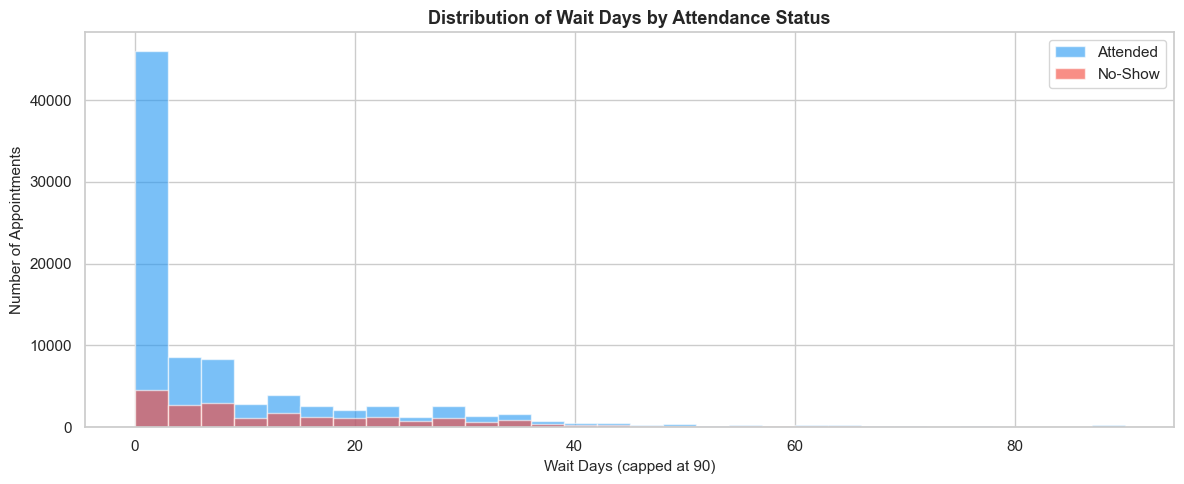

In [24]:
# Average wait days by no-show status
# Finding: No-show patients waited almost twice as long on average
# Attended: 8.8 days | No-Show: 15.8 days
wait_by_noshow = df.groupby('no_show')['wait_days'].mean()
wait_by_noshow.index = ['Attended', 'No-Show']

print('Average wait days by attendance status:')
print(wait_by_noshow.round(1))

# Visualisation: Wait days distribution
fig, ax = plt.subplots()
df[df['no_show'] == 0]['wait_days'].clip(0, 90).hist(
    bins=30, alpha=0.6, label='Attended', color='#2196F3', ax=ax
)
df[df['no_show'] == 1]['wait_days'].clip(0, 90).hist(
    bins=30, alpha=0.6, label='No-Show', color='#F44336', ax=ax
)
ax.set_title('Distribution of Wait Days by Attendance Status', fontweight='bold')
ax.set_xlabel('Wait Days (capped at 90)')
ax.set_ylabel('Number of Appointments')
ax.legend()
plt.tight_layout()
plt.show()

Top 15 clinics by no-show rate (min 100 appointments):
                   total_appointments  no_shows  no_show_rate
clinic                                                       
SANTOS DUMONT                    1276       369         28.92
SANTA CECÍLIA                     448       123         27.46
SANTA CLARA                       506       134         26.48
ITARARÉ                          3514       923         26.27
JESUS DE NAZARETH                2853       696         24.40
HORTO                             175        42         24.00
ILHA DO PRÍNCIPE                 2266       532         23.48
CARATOÍRA                        2565       591         23.04
ANDORINHAS                       2258       518         22.94
PRAIA DO SUÁ                     1288       294         22.83
GURIGICA                         2018       456         22.60
BENTO FERREIRA                    858       193         22.49
PARQUE MOSCOSO                    802       179         22.32
MARUÍPE        

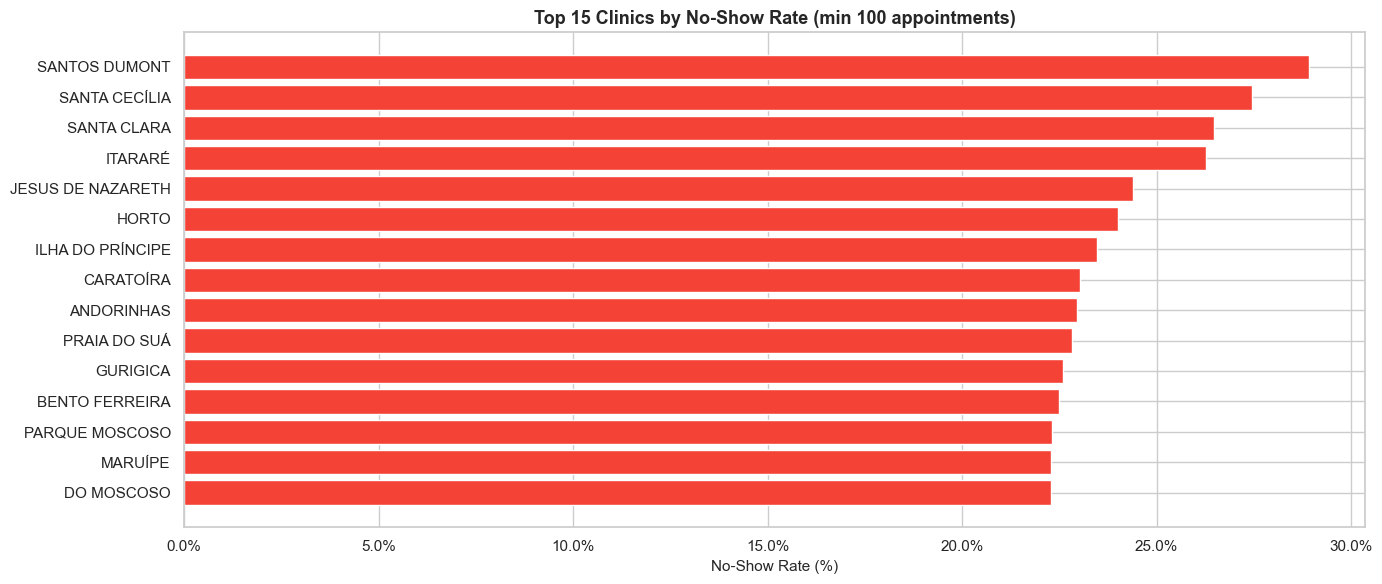

In [25]:
# Top 15 clinics by no-show rate
# Use this to identify where interventions should be prioritised
clinic_noshow = (
    df.groupby('clinic')
    .agg(
        total_appointments=('no_show', 'count'),
        no_shows=('no_show', 'sum')
    )
    .assign(no_show_rate=lambda x: (x['no_shows'] / x['total_appointments']) * 100)
    .query('total_appointments >= 100')   # Exclude clinics with very few records
    .sort_values('no_show_rate', ascending=False)
    .head(15)
)

print('Top 15 clinics by no-show rate (min 100 appointments):')
print(clinic_noshow.round(2))

# Visualisation
fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(
    clinic_noshow.index,
    clinic_noshow['no_show_rate'],
    color='#F44336'
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Top 15 Clinics by No-Show Rate (min 100 appointments)', fontweight='bold')
ax.set_xlabel('No-Show Rate (%)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

No-show rate by wait day band:
wait_band
Same Day        4.65
1-7 Days       24.14
8-14 Days      30.47
15-30 Days     32.59
31-90 Days     33.15
91-365 Days    25.81
Name: no_show, dtype: float64


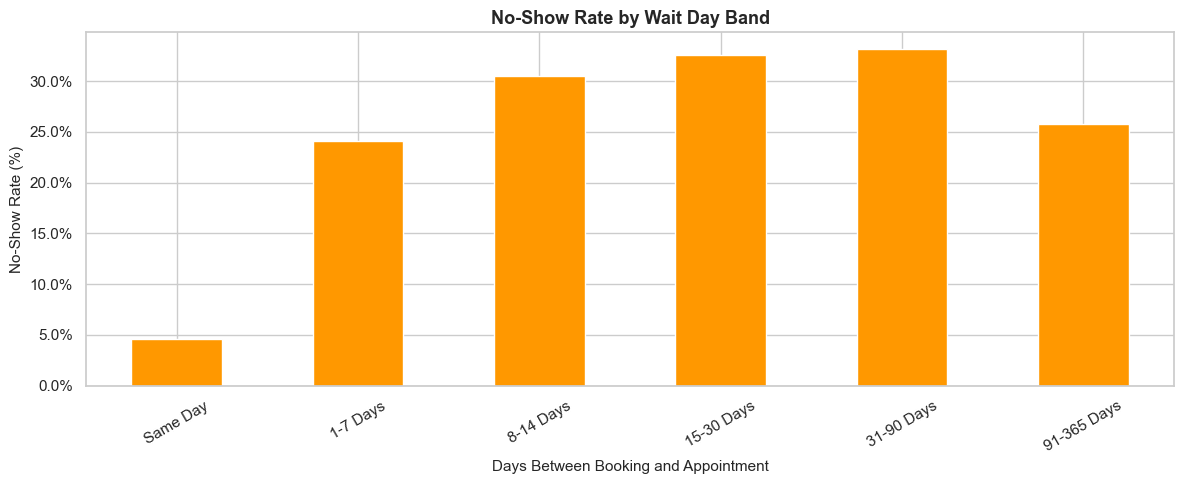

In [26]:
# No-show rate by wait day band
# Finding: No-show rates rise sharply beyond 14 days
bins   = [-1, 0, 7, 14, 30, 90, 365]
labels = ['Same Day', '1-7 Days', '8-14 Days', '15-30 Days', '31-90 Days', '91-365 Days']

df['wait_band'] = pd.cut(
    df['wait_days'].clip(-1, 365),
    bins=bins,
    labels=labels
)

band_noshow = df.groupby('wait_band', observed=True)['no_show'].mean() * 100

print('No-show rate by wait day band:')
print(band_noshow.round(2))

# Visualisation
fig, ax = plt.subplots()
band_noshow.plot(kind='bar', color='#FF9800', ax=ax, width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('No-Show Rate by Wait Day Band', fontweight='bold')
ax.set_xlabel('Days Between Booking and Appointment')
ax.set_ylabel('No-Show Rate (%)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 6. Export Cleaned Dataset

In [28]:
# Drop the wait_band column before export as it is a notebook-only label
export_df = df.drop(columns=['wait_band'])

# Save cleaned dataset
export_df.to_csv('appointments_cleaned.csv', index=False)

print(f'Cleaned dataset exported: {len(export_df)} rows, {export_df.shape[1]} columns')
print('\nFinal column list:')
print(export_df.columns.tolist())

# Preview final dataset
export_df.head()

Cleaned dataset exported: 110519 rows, 15 columns

Final column list:
['patient_id', 'appointment_id', 'gender', 'scheduled_date', 'appointment_date', 'age', 'clinic', 'scholarship', 'hipertension', 'diabetes', 'alcoholism', 'handcap', 'sms_received', 'no_show', 'wait_days']


,patient_id,appointment_id,gender,scheduled_date,appointment_date,age,clinic,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,no_show,wait_days
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,0,0,0,0,0,0,0,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0
